# Tesla Stock Price Analysis

### Exploratory Data Analysis of Tesla Historical Stock Performance

**Tools:** Python | Pandas | NumPy | Matplotlib | Jupyter Notebook

**Dataset:** Tesla historical stock price data

**Objective:** Analyze Tesla's historical price performance, returns, volatility, trading volume, and intraday price movements to identify meaningful patterns and trends.

## Business Questions

This analysis aims to answer the following questions:

1. How has Tesla's stock price changed over time?
2. Which years experienced the strongest and weakest average daily returns?
3. How volatile has Tesla's stock been historically?
4. How has trading volume changed over time?
5. Is trading volume associated with daily returns?
6. Is trading volume associated with larger intraday price movements?
7. Are there noticeable patterns in monthly and yearly performance?

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [2]:
df = pd.read_csv("Tesla_stock_data.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


## 3. Understanding the Dataset

The dataset contains daily historical trading information for Tesla (TSLA).

Each row represents one trading day.

### Main Variables

- **Date:** Trading date
- **Open:** Price at the beginning of the trading session
- **High:** Highest price reached during the day
- **Low:** Lowest price reached during the day
- **Close:** Closing price at the end of the trading session
- **Volume:** Number of Tesla shares traded during the day

In [3]:
df.shape

(3920, 6)

In [4]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3920 entries, 0 to 3919
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3920 non-null   object 
 1   Close   3920 non-null   float64
 2   High    3920 non-null   float64
 3   Low     3920 non-null   float64
 4   Open    3920 non-null   float64
 5   Volume  3920 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 183.9+ KB


## 4. Data Quality Check

Before analyzing the stock data, the dataset was checked for:

- Missing values
- Duplicate records
- Correct data types

In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Duplicate rows:
0


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3920 entries, 0 to 3919
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3920 non-null   datetime64[ns]
 1   Close   3920 non-null   float64       
 2   High    3920 non-null   float64       
 3   Low     3920 non-null   float64       
 4   Open    3920 non-null   float64       
 5   Volume  3920 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 183.9 KB


In [9]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [10]:
import pandas as pd

In [11]:
df.duplicated().sum()

0

In [12]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,3920,3920.000000,3920.000000,3920.000000,3920.000000,3.920000e+03
mean,2018-04-11 02:54:51.428571392,100.730383,102.948065,98.417660,100.756022,9.658169e+07
min,2010-06-29 00:00:00,1.053333,1.108667,0.998667,1.076000,1.777500e+06
25%,2014-05-20 18:00:00,12.841666,13.006000,12.577667,12.802500,5.145338e+07
50%,2018-04-11 12:00:00,20.011000,20.382000,19.610000,20.008667,8.301450e+07
75%,2022-03-02 06:00:00,209.460003,215.422504,204.951672,209.740002,1.208368e+08
max,2026-01-28 00:00:00,489.880005,498.829987,485.329987,489.880005,9.140820e+08
std,NaN,127.112639,129.924183,124.227781,127.202889,7.557290e+07


In [13]:
df['Close'].mean()

100.7303829868229

In [14]:
df['Close'].max()

489.8800048828125

In [15]:
df.loc[df['Close'].idxmax()]

Date      2025-12-16 00:00:00
Close              489.880005
High                    491.5
Low                465.829987
Open               472.209991
Volume              107608100
Name: 3891, dtype: object

In [16]:
df.loc[df['Close'].idxmin()]

Date      2010-07-07 00:00:00
Close                1.053333
High                 1.108667
Low                  0.998667
Open                 1.093333
Volume              103825500
Name: 5, dtype: object

In [17]:
round(df['Close'].mean(), 2)

100.73

### 5.1 Tesla Closing Price Over Time

The closing price is examined over time to understand Tesla's long-term stock price movement and major periods of price growth and decline.

In [18]:
import matplotlib.pyplot as plt

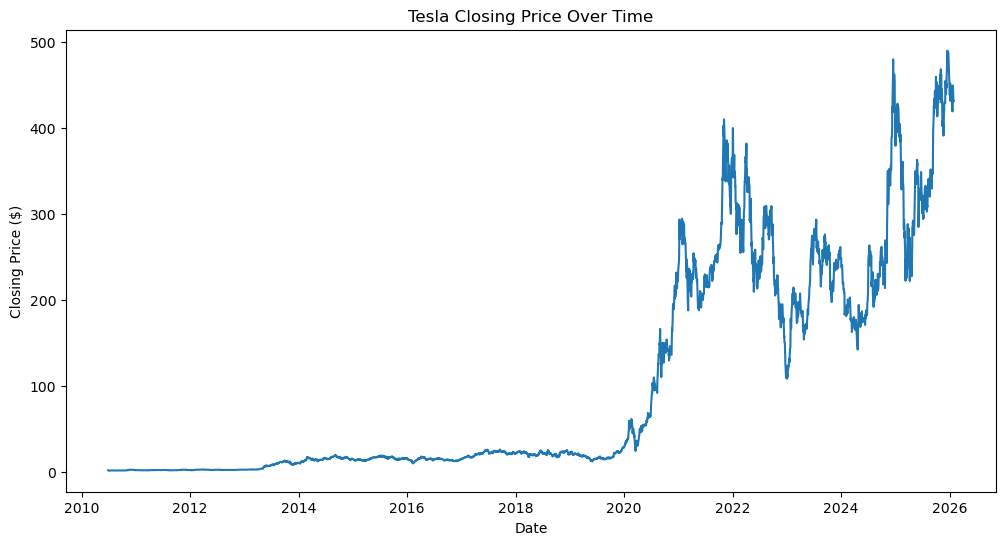

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Close'])

plt.title("Tesla Closing Price Over Time")

plt.xlabel("Date")

plt.ylabel("Closing Price ($)")

plt.show()

### Key Statistics

- Average closing price: **$100.73**
- Highest closing price: **$489.88**
- Lowest closing price: **$1.05**
- Total trading days: **3,920**

### Observation

Tesla's closing price remained relatively low during the earlier years of the dataset before experiencing substantial growth from around 2020 onward. The chart also shows several periods of significant price fluctuations, particularly during the years following 2020.

In [20]:
df['Year'] = df['Date'].dt.year

In [21]:
df.head()

,Date,Close,High,Low,Open,Volume,Year
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,2010
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,2010
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,2010
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,2010
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,2010


### 5.2 Average Closing Price by Year

To examine Tesla's long-term price progression, the average closing price was calculated for each year.

In [22]:
yearly_avg = df.groupby('Year')['Close'].mean()

In [23]:
yearly_avg

Year
2010      1.556123
2011      1.786984
2012      2.077907
2013      6.960082
2014     14.888606
2015     15.336193
2016     13.984484
2017     20.954420
2018     21.153995
2019     18.235347
2020     96.665689
2021    259.998162
2022    263.093081
2023    217.475240
2024    230.614961
2025    356.970760
2026    438.501112
Name: Close, dtype: float64

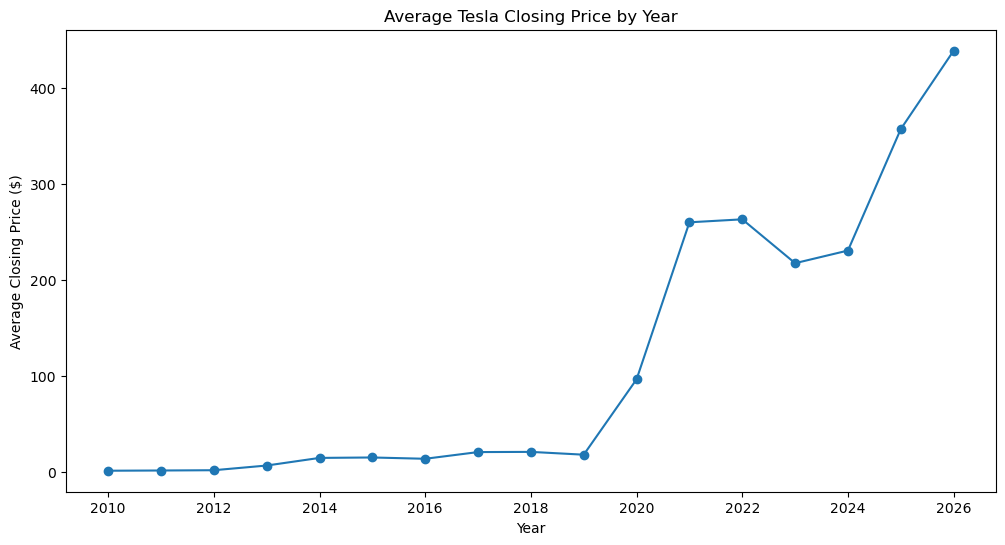

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(yearly_avg.index, yearly_avg.values, marker='o')

plt.title("Average Tesla Closing Price by Year")

plt.xlabel("Year")

plt.ylabel("Average Closing Price ($)")

plt.show()

### Observation

The yearly averages show a major increase in Tesla's average closing price beginning around 2020. The average price subsequently fluctuated across the following years, with substantial increases again in 2025 and 2026 within the dataset.

In [25]:
df['Daily_Change'] = df['Close'] - df['Open']

In [26]:
df.head()

,Date,Close,High,Low,Open,Volume,Year,Daily_Change
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,2010,0.326000
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,2010,-0.130666
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,2010,-0.202667
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,2010,-0.253333
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,2010,-0.259333


In [27]:
df.loc[df['Daily_Change'].idxmax()]

Date            2025-04-09 00:00:00
Close                    272.200012
High                     274.690002
Low                      223.880005
Open                     224.690002
Volume                    219433400
Year                           2025
Daily_Change               47.51001
Name: 3718, dtype: object

In [28]:
df.loc[df['Daily_Change'].idxmin()]

Date            2021-11-09 00:00:00
Close                    341.166656
High                          391.5
Low                       337.17334
Open                     391.200012
Volume                    177317400
Year                           2021
Daily_Change             -50.033356
Name: 2862, dtype: object

### 5.3 Daily Returns

Daily return measures the percentage change in Tesla's closing price from one trading day to the next.

Daily returns help identify periods of strong gains, losses, and short-term price fluctuations.

In [29]:
df['Daily_Return'] = df['Close'].pct_change() * 100

In [30]:
df.head()

,Date,Close,High,Low,Open,Volume,Year,Daily_Change,Daily_Return
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,2010,0.326000,NaN
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,2010,-0.130666,-0.251148
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,2010,-0.202667,-7.847274
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,2010,-0.253333,-12.568307
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,2010,-0.259333,-16.093748


In [31]:
round(df['Daily_Return'].mean(), 2)

0.21

In [32]:
df.loc[df['Daily_Return'].idxmax()]

Date            2013-05-09 00:00:00
Close                      4.626667
High                       5.051333
Low                           4.246
Open                       4.674667
Volume                    429075000
Year                           2013
Daily_Change                 -0.048
Daily_Return              24.395076
Name: 720, dtype: object

In [33]:
df.loc[df['Daily_Return'].idxmin()]

Date            2020-09-08 00:00:00
Close                        110.07
High                      122.91333
Low                      109.959999
Open                     118.666664
Volume                    346397100
Year                           2020
Daily_Change              -8.596664
Daily_Return             -21.062824
Name: 2566, dtype: object

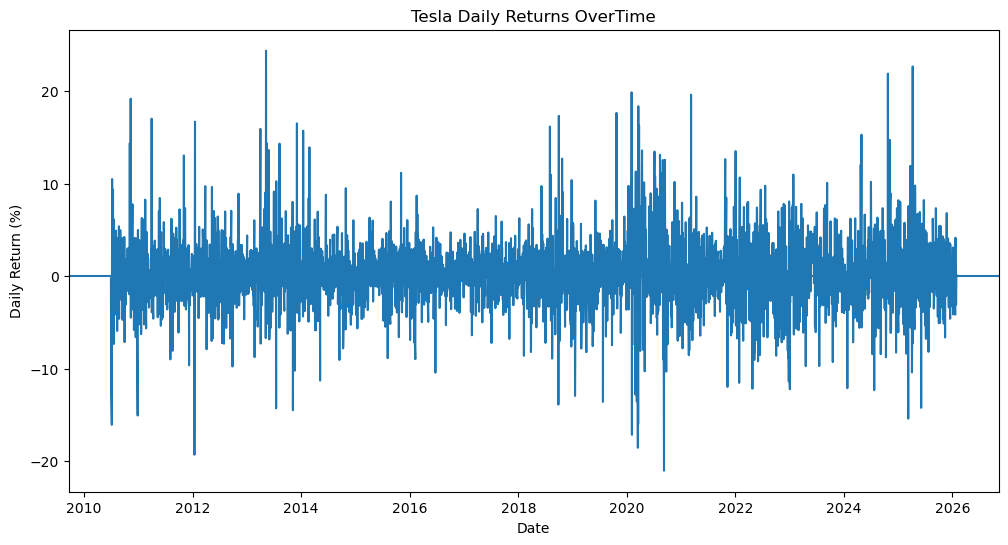

In [34]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Daily_Return'])

plt.title("Tesla Daily Returns OverTime")

plt.xlabel("Date")

plt.ylabel("Daily Return (%)")

plt.axhline(y=0)

plt.show()

### Key Findings

- Average daily return: **0.21%**
- Highest daily return: **24.40% on May 9, 2013**
- Lowest daily return: **-21.68% on September 8, 2020**
- The daily return chart shows that most daily movements were relatively close to zero, with occasional large positive and negative movements.

### 5.4 Volatility Analysis

Volatility measures how much Tesla's daily returns fluctuate over time.

Standard deviation is used to measure the overall variation in daily returns, while a 30-day rolling standard deviation is used to examine how volatility changes over time.

In [35]:
round(df['Daily_Return'].std(), 2)

3.63

In [36]:
df['Rolling_Volatility'] = df['Daily_Return'].rolling(window=30).std()

In [37]:
df.tail()

,Date,Close,High,Low,Open,Volume,Year,Daily_Change,Daily_Return,Rolling_Volatility
3915,2026-01-22,449.359985,449.500000,432.630005,435.160004,71546700,2026,14.199982,4.153528,2.449019
3916,2026-01-23,449.059998,452.429993,444.040009,447.429993,56771400,2026,1.630005,-0.066759,2.439156
3917,2026-01-26,435.200012,445.040009,434.279999,445.000000,49397400,2026,-9.799988,-3.086444,2.490790
3918,2026-01-27,430.899994,437.519989,430.690002,437.410004,37733100,2026,-6.510010,-0.988056,2.490514
3919,2026-01-28,431.459991,438.260010,430.100006,431.910004,53657900,2026,-0.450012,0.129960,2.434729


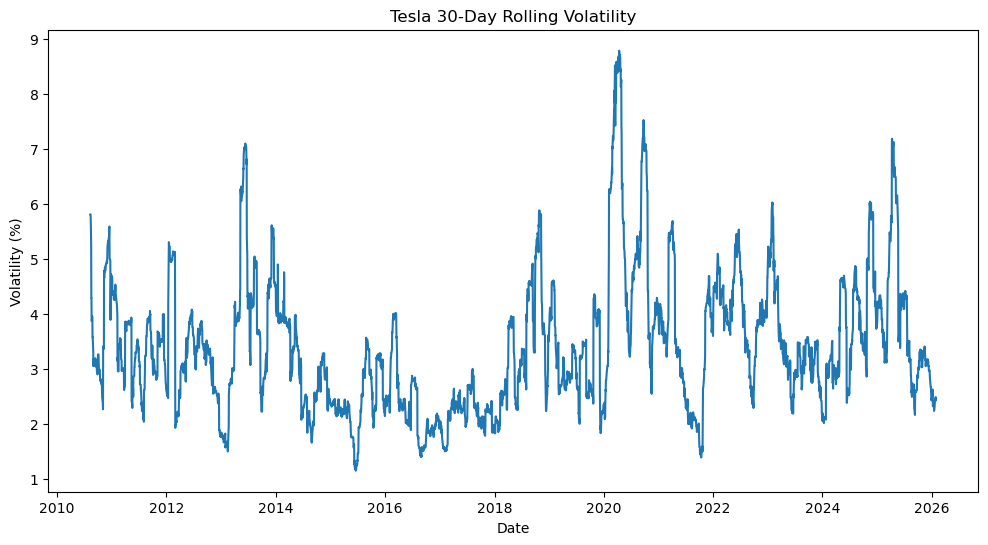

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Rolling_Volatility'])

plt.title("Tesla 30-Day Rolling Volatility")

plt.xlabel("Date")

plt.ylabel("Volatility (%)")

plt.show()

### Observation

Tesla's volatility varied considerably over time. The rolling-volatility chart shows several periods of elevated fluctuations, particularly around 2020, while other periods experienced comparatively lower volatility.

The overall standard deviation of daily returns was approximately **3.63%**.

### 5.5 Trading Volume

Trading volume represents the number of Tesla shares traded during each trading day.

Analyzing trading volume helps identify periods of unusually high or low market activity and allows us to examine whether trading activity is associated with larger price movements.

In [39]:
round(df['Volume'].mean(), 2)

96581685.26

In [40]:
df.loc[df['Volume'].idxmax()]

Date                  2020-02-04 00:00:00
Close                           59.137333
High                            64.599335
Low                             55.591999
Open                            58.863998
Volume                          914082000
Year                                 2020
Daily_Change                     0.273335
Daily_Return                     13.72564
Rolling_Volatility               5.095025
Name: 2416, dtype: object

In [41]:
df.loc[df['Volume'].idxmin()]

Date                  2010-10-25 00:00:00
Close                                1.39
High                             1.398667
Low                                 1.382
Open                                1.396
Volume                            1777500
Year                                 2010
Daily_Change                       -0.006
Daily_Return                     0.627437
Rolling_Volatility                2.72271
Name: 82, dtype: object

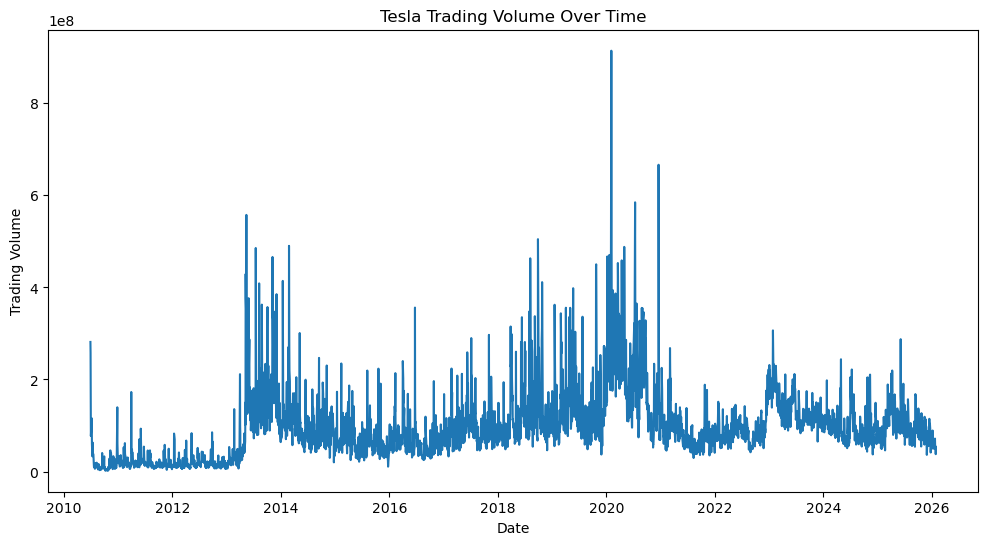

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Volume'])

plt.title("Tesla Trading Volume Over Time")

plt.xlabel("Date")

plt.ylabel("Trading Volume")

plt.show()

### Key Findings

- Average daily trading volume was approximately **96.58 million shares**.
- The highest trading volume occurred on **February 4, 2020**, with approximately **914.08 million shares traded**.
- Trading volume increased substantially during several periods of Tesla's history, particularly around 2020–2021.
- High trading activity was often associated with larger intraday price movements, although trading volume alone does not explain all changes in price.

In [43]:
import pandas as pd

tesla = pd.read_csv('Tesla_stock_data.csv')

tesla['Date'] = pd.to_datetime(tesla['Date'])

tesla['Price_Range_Percent'] = (
    (tesla['High'] - tesla['Low']) / tesla['Open']
) * 100

volume_range_corr = tesla['Volume'].corr(tesla['Price_Range_Percent'])

print("Volume vs Price Range Correlation:", round(volume_range_corr, 2))

Volume vs Price Range Correlation: 0.5


In [44]:
print("Rows:", len(df))

print("\nColumns:")
print(df.columns.tolist())

print("\nCorrelation calculated directly:")
print(
    round(
        df['Volume'].corr(
            ((df['High'] - df['Low']) / df['Open']) * 100
        ),
        2
    )
)

Rows: 3920

Columns:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Year', 'Daily_Change', 'Daily_Return', 'Rolling_Volatility']

Correlation calculated directly:
0.5


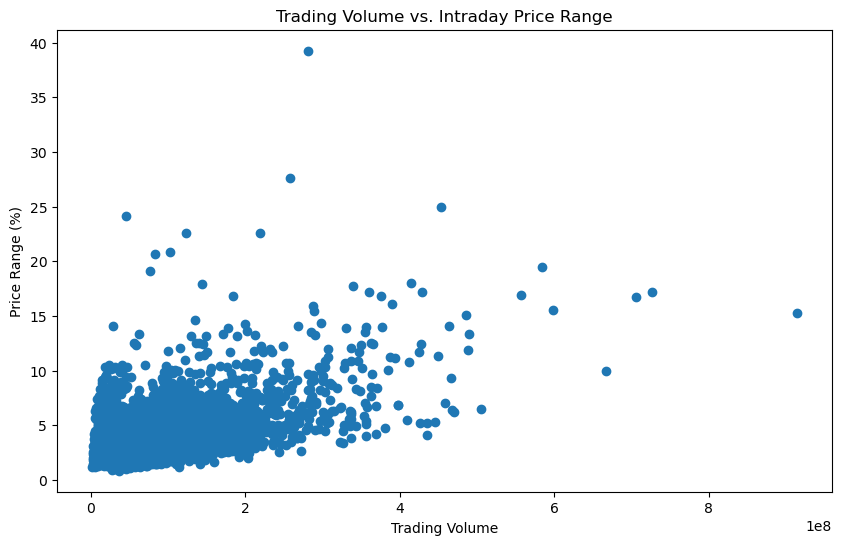

In [45]:
plt.figure(figsize=(10, 6))

plt.scatter(tesla['Volume'], tesla['Price_Range_Percent'])

plt.title('Trading Volume vs. Intraday Price Range')
plt.xlabel('Trading Volume')
plt.ylabel('Price Range (%)')

plt.show()

## Volume and Intraday Price Movement

The correlation between trading volume and intraday price range was 0.50, indicating a moderate positive linear relationship.

This suggests that days with higher trading volume tended to experience larger intraday price movements. However, correlation does not imply causation, so trading volume alone cannot be used to explain changes in intraday price movement.

In [46]:
df['Volume'].corr(df['Daily_Return'])

0.08237733119501417

In [47]:
round(df['Volume'].corr(df['Daily_Return']), 2)

0.08

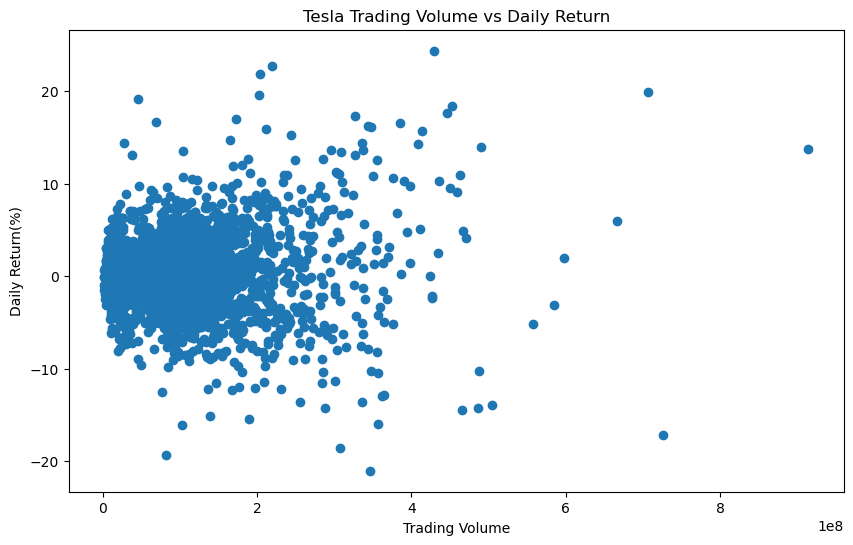

In [48]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Volume'], df['Daily_Return'])

plt.title("Tesla Trading Volume vs Daily Return")

plt.xlabel("Trading Volume")

plt.ylabel("Daily Return(%)")

plt.show()

### 5.6 Yearly and Monthly Performance

Tesla's average daily returns were analyzed by year and month to identify differences in historical performance across time periods.

In [49]:
yearly_return = df.groupby('Year')['Daily_Return'].mean()

In [50]:
round(yearly_return, 2)

Year
2010    0.19
2011    0.08
2012    0.12
2013    0.68
2014    0.20
2015    0.06
2016   -0.02
2017    0.17
2018    0.09
2019    0.14
2020    1.00
2021    0.22
2022   -0.33
2023    0.34
2024    0.27
2025    0.12
2026   -0.20
Name: Daily_Return, dtype: float64

In [51]:
yearly_return.idxmax()

2020

In [52]:
round(yearly_return.max(), 2)

1.0

In [53]:
yearly_return.idxmin()

2022

In [54]:
round(yearly_return.min(), 2)

-0.33

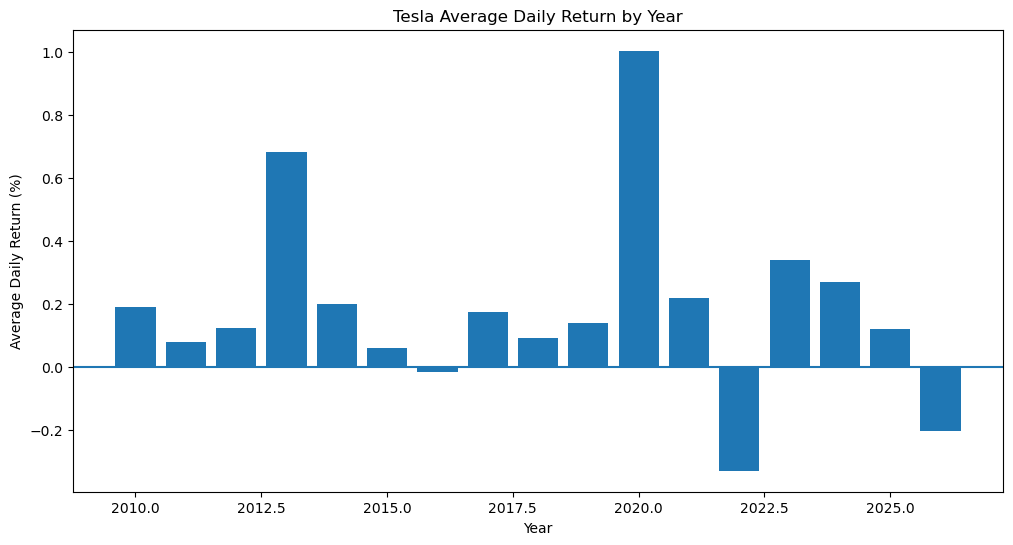

In [55]:
plt.figure(figsize=(12, 6))

plt.bar(yearly_return.index, yearly_return.values)

plt.title("Tesla Average Daily Return by Year")

plt.xlabel("Year")

plt.ylabel("Average Daily Return (%)")

plt.axhline(y=0)

plt.show()

In [56]:
df['Month'] = df['Date'].dt.month

### Yearly Performance Findings

- **2020** had the highest average daily return at approximately **1.00%**.
- **2022** had the lowest average daily return at approximately **-0.33%**.
- Average daily returns varied considerably across years.
- **2026 represents only a partial year in this dataset**, ending on January 28, so it should not be directly compared with complete calendar years.

### 5.7 Monthly Performance

Average daily returns were also grouped by calendar month to examine whether historical performance differed across months.

In [57]:
df[['Date', 'Month']].head()

,Date,Month
0,2010-06-29,6
1,2010-06-30,6
2,2010-07-01,7
3,2010-07-02,7
4,2010-07-06,7


In [58]:
monthly_return = df.groupby('Month')['Daily_Return'].mean()

In [59]:
round(monthly_return, 2)

Month
1     0.25
2     0.10
3    -0.00
4     0.29
5     0.25
6     0.43
7     0.20
8     0.25
9     0.14
10    0.10
11    0.48
12    0.03
Name: Daily_Return, dtype: float64

In [60]:
monthly_return.idxmax()

11

In [61]:
round(monthly_return.max(), 2)

0.48

In [62]:
monthly_return.idxmin()

3

In [63]:
round(monthly_return.min(), 2)

-0.0

In [64]:
import calendar

In [65]:
monthly_return.index = monthly_return.index.map(lambda x: calendar.month_abbr[x])

In [66]:
monthly_return

Month
Jan    0.245761
Feb    0.100246
Mar   -0.004457
Apr    0.291098
May    0.250609
Jun    0.428545
Jul    0.203494
Aug    0.247552
Sep    0.138895
Oct    0.102790
Nov    0.476485
Dec    0.032996
Name: Daily_Return, dtype: float64

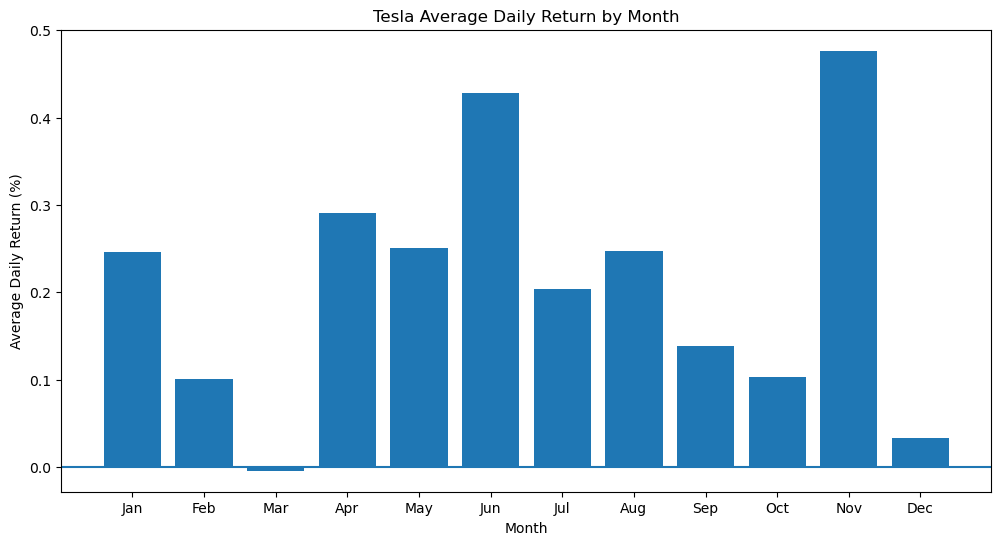

In [67]:
plt.figure(figsize=(12, 6))

plt.bar(monthly_return.index, monthly_return.values)

plt.title("Tesla Average Daily Return by Month")

plt.xlabel("Month")

plt.ylabel("Average Daily Return (%)")

plt.axhline(y=0)

plt.show()

## 6. Key Findings

- Tesla's closing price experienced substantial long-term growth during the period analyzed, although the stock also experienced significant periods of volatility.
- The average daily return was approximately 0.21%, with a standard deviation of approximately 3.63%, indicating considerable day-to-day price variation.
- Trading volume averaged approximately 96.58 million shares per day.
- The highest trading volume occurred on February 4, 2020, with approximately 914.08 million shares traded.
- Trading volume had a very weak positive correlation (0.08) with daily returns, suggesting that trading volume alone had little linear relationship with daily percentage returns.
- Trading volume had a moderate positive correlation (0.50) with intraday price range percentage, suggesting that higher-volume days tended to experience larger price movements within the trading day.
- 2020 recorded the highest average daily return among the years analyzed, while 2022 recorded the lowest.
- November recorded the highest average monthly return, while March recorded the lowest.

### Monthly Performance Findings

- **November** had the highest historical average daily return at approximately **0.48%**.
- **June** had the second-highest average at approximately **0.43%**.
- **March** had the lowest average daily return at approximately **-0.08%**.
- These figures describe historical averages and should not be interpreted as evidence that a particular month will perform the same way in the future.

In [68]:
positive_days = (df['Daily_Change'] > 0).sum()

In [69]:
positive_days

1944

In [70]:
positive_percentage = (positive_days / len(df)) * 100

In [71]:
round(positive_percentage, 2)

49.59

In [72]:
negative_days = (df['Daily_Change'] < 0).sum()

In [73]:
negative_days

1969

In [74]:
negative_percentage = (negative_days / len(df)) * 100

In [75]:
round(negative_percentage, 2)

50.23

In [76]:
unchanged_days = (df['Daily_Change'] == 0).sum()

In [77]:
unchanged_days

7

In [78]:
positive_days + negative_days + unchanged_days

3920

In [79]:
unchanged_percentage = (unchanged_days / len(df)) * 100

In [80]:
round(unchanged_percentage, 2)

0.18

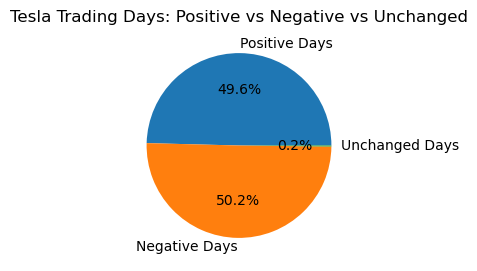

In [81]:
labels = ['Positive Days', 'Negative Days', 'Unchanged Days']
sizes = [positive_days, negative_days, unchanged_days]

plt.figure(figsize=(8,3))

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title("Tesla Trading Days: Positive vs Negative vs Unchanged")

plt.show()

In [82]:
df['Price_Range'] = df['High'] - df['Low']

In [83]:
df[['Date', 'High', 'Low', 'Price_Range']].head()

,Date,High,Low,Price_Range
0,2010-06-29,1.666667,1.169333,0.497334
1,2010-06-30,2.028000,1.553333,0.474667
2,2010-07-01,1.728000,1.351333,0.376667
3,2010-07-02,1.540000,1.247333,0.292667
4,2010-07-06,1.333333,1.055333,0.278000


In [84]:
round(df['Price_Range'].mean(), 2)

4.53

In [85]:
df.loc[df['Price_Range'].idxmax()]

Date                  2024-12-18 00:00:00
Close                          440.130005
High                           488.540009
Low                             427.01001
Open                                466.5
Volume                          149340800
Year                                 2024
Daily_Change                   -26.369995
Daily_Return                    -8.279494
Rolling_Volatility               4.772018
Month                                  12
Price_Range                     61.529999
Name: 3643, dtype: object

In [86]:
df['Price_Range_Percent'] = (df['High'] - df['Open']) / df['Open'] * 100

In [87]:
df[['Date', 'Open', 'High', 'Low', 'Price_Range_Percent']].head()

,Date,Open,High,Low,Price_Range_Percent
0,2010-06-29,1.266667,1.666667,1.169333,31.578937
1,2010-06-30,1.719333,2.028000,1.553333,17.952721
2,2010-07-01,1.666667,1.728000,1.351333,3.679983
3,2010-07-02,1.533333,1.540000,1.247333,0.434806
4,2010-07-06,1.333333,1.333333,1.055333,0.000000


In [88]:
df.loc[df['Price_Range_Percent'].idxmax()]

Date                   2010-06-29 00:00:00
Close                             1.592667
High                              1.666667
Low                               1.169333
Open                              1.266667
Volume                           281494500
Year                                  2010
Daily_Change                         0.326
Daily_Return                           NaN
Rolling_Volatility                     NaN
Month                                    6
Price_Range                       0.497334
Price_Range_Percent              31.578937
Name: 0, dtype: object

In [89]:
round(df['Price_Range_Percent'].max(), 2)

31.58

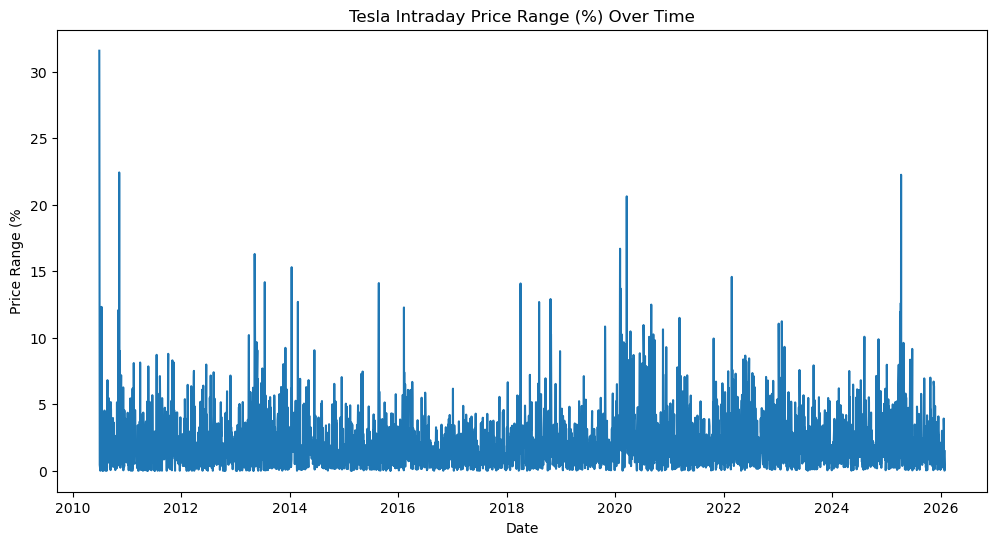

In [90]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Price_Range_Percent'])

plt.title("Tesla Intraday Price Range (%) Over Time")

plt.xlabel("Date")

plt.ylabel("Price Range (%")

plt.show()

           

In [91]:
yearly_volatility = df.groupby('Year')['Price_Range_Percent'].mean()

In [92]:
round(yearly_volatility, 2)

Year
2010    2.88
2011    2.09
2012    1.95
2013    2.37
2014    1.88
2015    1.57
2016    1.65
2017    1.34
2018    2.08
2019    1.71
2020    3.06
2021    2.02
2022    2.48
2023    2.19
2024    2.13
2025    2.30
2026    1.38
Name: Price_Range_Percent, dtype: float64

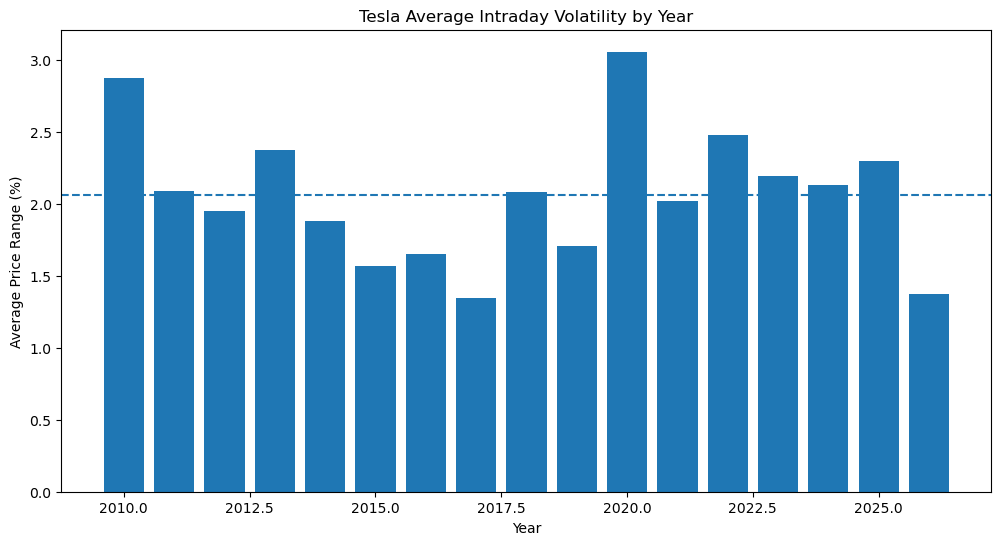

In [93]:
plt.figure(figsize=(12, 6))

plt.bar(yearly_volatility.index, yearly_volatility.values)

plt.title("Tesla Average Intraday Volatility by Year")

plt.xlabel("Year")

plt.ylabel("Average Price Range (%)")

plt.axhline(yearly_volatility.mean(), linestyle='--')

plt.show()

In [94]:
volume_range_corr = df['Volume'].corr(df['Price_Range_Percent'])

round(volume_range_corr, 2)

0.32

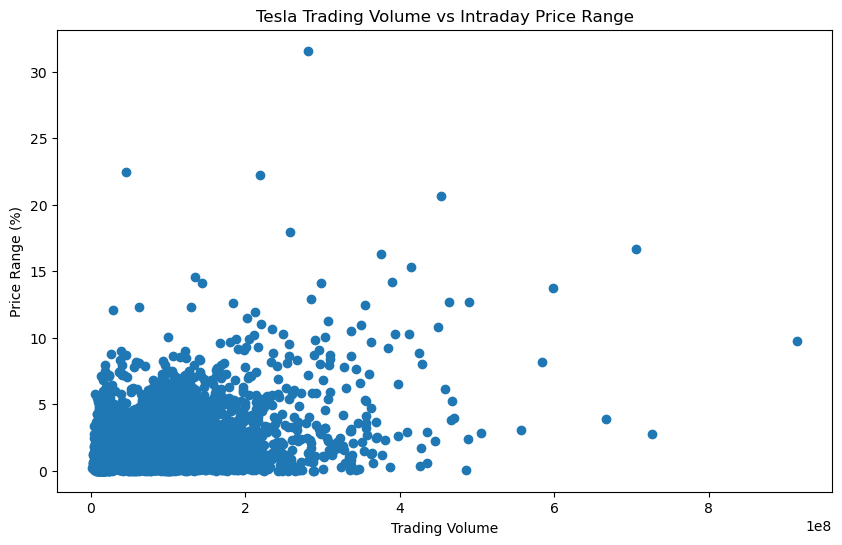

In [95]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Volume'], df['Price_Range_Percent'])

plt.title("Tesla Trading Volume vs Intraday Price Range")

plt. xlabel("Trading Volume")

plt.ylabel("Price Range (%)")

plt.show()

In [96]:
round(df['Volume'].mean(), 0)

96581685.0

In [97]:
df.loc[df['Volume'].idxmax()]

Date                   2020-02-04 00:00:00
Close                            59.137333
High                             64.599335
Low                              55.591999
Open                             58.863998
Volume                           914082000
Year                                  2020
Daily_Change                      0.273335
Daily_Return                      13.72564
Rolling_Volatility                5.095025
Month                                    2
Price_Range                       9.007336
Price_Range_Percent               9.743369
Name: 2416, dtype: object

In [98]:
df['Volume_Category'] = df['Volume'].apply(
    lambda x: 'High Volume' if x > df['Volume'].mean() else 'Normal Volume'
)

In [99]:
df.groupby('Volume_Category')['Price_Range_Percent'].mean().round(2)

Volume_Category
High Volume      2.65
Normal Volume    1.71
Name: Price_Range_Percent, dtype: float64

In [100]:
yearly_summary = df.groupby('Year').agg({
    'Close': 'mean',
    'Daily_Return': 'mean',
    'Price_Range_Percent': 'mean',
    'Volume': 'mean'
})    

In [101]:
yearly_summary.round(2)

,Close,Daily_Return,Price_Range_Percent,Volume
Year,,,,
2010,1.56,0.19,2.88,2.369643e+07
2011,1.79,0.08,2.09,1.935923e+07
2012,2.08,0.12,1.95,1.844694e+07
2013,6.96,0.68,2.37,1.261158e+08
2014,14.89,0.20,1.88,1.037096e+08
2015,15.34,0.06,1.57,6.477487e+07
2016,13.98,-0.02,1.65,6.918820e+07
2017,20.95,0.17,1.34,9.502180e+07
2018,21.15,0.09,2.08,1.291816e+08


In [102]:
print("TESLA STOCK DATA ANALYSIS - KEY METRICS")
print("----------------------------------------")

print("Total trading days:", len(df))

print("Average closing price: $", round(df['Close'].mean(), 2))

print("Highest closing price: $", round(df['Close'].mean(), 2))

print("Lowest closing price: $", round(df['Close'].min(), 2))

print("Average daily return:", round(df['Daily_Return'].mean(), 2), "%")

print("Average daily price range: $", round(df['Price_Range'].mean(), 2))

print("Average intraday range:", round(df['Price_Range_Percent'].mean(), 2), "%")

print("Average trading volume:", round(df['Volume'].mean(), 0))

print("Volume vs intraday range correlation:", round(volume_range_corr, 2))

print("Positive trading days:", positive_days)

print("Negative trading days:", negative_days)

TESLA STOCK DATA ANALYSIS - KEY METRICS
----------------------------------------
Total trading days: 3920
Average closing price: $ 100.73
Highest closing price: $ 100.73
Lowest closing price: $ 1.05
Average daily return: 0.21 %
Average daily price range: $ 4.53
Average intraday range: 2.08 %
Average trading volume: 96581685.0
Volume vs intraday range correlation: 0.32
Positive trading days: 1944
Negative trading days: 1969


In [103]:
print("Average closing price: $", round(df['Close'].mean(), 2))
print("Highest closing price: $", round(df['Close'].max(), 2))
print("Lowest closing price: $", round(df['Close'].min(), 2))

Average closing price: $ 100.73
Highest closing price: $ 489.88
Lowest closing price: $ 1.05


In [104]:
df.to_csv('Tesla_Stock_Analysis_Cleaned.csv', index=False)

In [105]:
df.head()

,Date,Close,High,Low,Open,Volume,Year,Daily_Change,Daily_Return,Rolling_Volatility,Month,Price_Range,Price_Range_Percent,Volume_Category
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,2010,0.326000,NaN,NaN,6,0.497334,31.578937,High Volume
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,2010,-0.130666,-0.251148,NaN,6,0.474667,17.952721,High Volume
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,2010,-0.202667,-7.847274,NaN,7,0.376667,3.679983,High Volume
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,2010,-0.253333,-12.568307,NaN,7,0.292667,0.434806,Normal Volume
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,2010,-0.259333,-16.093748,NaN,7,0.278000,0.000000,High Volume


In [106]:
df.to_csv('Tesla_Stock_Analysis_Cleaned.csv', index=False)

In [107]:
print(df.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Year', 'Daily_Change', 'Daily_Return', 'Rolling_Volatility', 'Month', 'Price_Range', 'Price_Range_Percent', 'Volume_Category']


## 7. Conclusion

This project analyzed Tesla's historical stock price data to identify trends in price performance, daily returns, volatility, trading volume, and intraday price movements.

The analysis showed substantial long-term changes in Tesla's stock price, accompanied by periods of elevated volatility. Trading volume showed only a very weak relationship with daily returns but demonstrated a stronger positive relationship with intraday price range.

This project demonstrates the use of Python and pandas for data cleaning, exploratory data analysis, statistical analysis, and visualization. The findings are descriptive and should not be interpreted as investment advice or predictions of future stock performance.

## 8. Skills Demonstrated

- Python
- Pandas
- NumPy
- Matplotlib
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Descriptive Statistics
- Correlation Analysis
- Time-Series Analysis
- Data Visualization
- Jupyter Notebook
- Business Insight Generation